# SFNO for Ocean O2 Reconstruction — Single Depth Level (Simple)

Spherical Fourier Neural Operator (SFNO) that maps monthly T/S fields → O2 fields
on the native 180×360 lat/lon grid, trained at a single depth level.

**Split:** 11 randomly chosen years held out for validation; remaining years for training.

In [1]:
import subprocess, sys
try:
    import torch_harmonics
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-harmonics"])
    import torch_harmonics

print(f"torch-harmonics version: {torch_harmonics.__version__}")

torch-harmonics version: 0.9.0


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_harmonics import RealSHT, InverseRealSHT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT  = Path("/glade/campaign/univ/ugit0034")
EN4_DIR    = DATA_ROOT / "EN4/L09_20x180x360"
O2_OSD     = DATA_ROOT / "WOD_O2_2022-25/Oxygen_1x1bin_osd_1965-2025.nc"
O2_CTD     = DATA_ROOT / "WOD_O2_2022-25/Oxygen_1x1bin_ctd_1987-2025.nc"
O2_PFL     = DATA_ROOT / "WOD_O2_2022-25/Oxygen_1x1bin_pfl_2005-2025.nc"
SAVE_DIR   = Path("/glade/derecho/scratch") / Path.home().name / "ML4O2_sfno_simple"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Depth level ────────────────────────────────────────────────────────────
DEPTH_VAL = 400
ds0 = xr.open_dataset(f'{EN4_DIR}/EN4_TSN2_L09_180x360_196501.nc')
z0  = ds0.depth.to_numpy()
DEPTH_IDX = np.argmin(np.abs(z0 - DEPTH_VAL))

# ── Grid ───────────────────────────────────────────────────────────────────
NLAT, NLON = 180, 360

# ── Spectral truncation ────────────────────────────────────────────────────
LMAX = NLAT // 2
MMAX = LMAX

# ── Validation split ───────────────────────────────────────────────────────
VAL_YEARS_N = 11   # number of years randomly held out for validation
VAL_SEED    = 42

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
EPOCHS       = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-3
LAMBDA_GRAD  = 1.0
PATIENCE     = 8

# ── Model ──────────────────────────────────────────────────────────────────
IN_CHANNELS  = 5    # T, S, cos(month), sin(month), linear time
OUT_CHANNELS = 1
HIDDEN_CH    = 16
N_BLOCKS     = 2
DROPOUT      = 0.1

print("Configuration ready.")

Configuration ready.


## 2. Data Loading

In [4]:
def load_en4_single_depth(en4_dir: Path, depth_idx: int):
    files = sorted(en4_dir.glob("EN4_TSN2_L09_180x360_*.nc"))
    if not files:
        raise FileNotFoundError(f"No EN4 files found in {en4_dir}")

    T_list, S_list, times = [], [], []
    depth_val = None

    for f in files:
        ds = xr.open_dataset(f)
        if depth_val is None:
            depth_val = float(ds.depth.values[depth_idx])
        T_list.append(ds["CT"].isel(depth=depth_idx).values.squeeze().astype(np.float32))
        S_list.append(ds["SA"].isel(depth=depth_idx).values.squeeze().astype(np.float32))
        ym = f.stem.split("_")[-1]
        times.append((int(ym[:4]), int(ym[4:])))
        ds.close()

    T = np.stack(T_list)   # [Nt, 180, 360]
    S = np.stack(S_list)
    print(f"EN4 loaded: {T.shape},  depth ≈ {depth_val:.1f} m")
    return T, S, times, depth_val


def load_o2_single_depth(o2_paths: list, depth_idx: int, times: list):
    def _read(path):
        ds = xr.open_dataset(path)
        for vname in ["Oxygen", "oxygen", "o2", "O2"]:
            if vname in ds:
                return ds[vname].isel(depth=depth_idx).values.astype(np.float32), ds
        raise KeyError(f"O2 variable not found in {path}")

    arrays = []
    for path in o2_paths:
        if not Path(path).exists():
            continue
        arr, ds = _read(path)
        file_times = [(int(t.dt.year), int(t.dt.month)) for t in ds.time]
        time_map   = {ym: i for i, ym in enumerate(file_times)}
        aligned    = np.full((len(times), NLAT, NLON), np.nan, dtype=np.float32)
        for j, ym in enumerate(times):
            if ym in time_map:
                aligned[j] = arr[time_map[ym]]
        arrays.append(aligned)
        ds.close()

    if not arrays:
        raise RuntimeError("No O2 files found / loaded.")

    stack = np.stack(arrays)
    O2    = np.nanmean(stack, axis=0)
    O2[np.all(np.isnan(stack), axis=0)] = np.nan
    print(f"O2  loaded: {O2.shape},  valid frac = {np.isfinite(O2).mean():.2%}")
    return O2


T_maps, S_maps, times, depth_val = load_en4_single_depth(EN4_DIR, DEPTH_IDX)
O2_maps = load_o2_single_depth([O2_OSD, O2_CTD, O2_PFL], DEPTH_IDX, times)

years  = np.array([t[0] for t in times])
months = np.array([t[1] for t in times])

EN4 loaded: (672, 180, 360),  depth ≈ 400.0 m
O2  loaded: (672, 180, 360),  valid frac = 0.69%


/glade/derecho/scratch/ito/tmp/ipykernel_79957/1564568471.py:51: RuntimeWarning: Mean of empty slice
  O2    = np.nanmean(stack, axis=0)


## 3. Year-Based Train / Val Split & Normalisation

11 years are drawn at random (fixed seed) for validation; all remaining years are used
for training. Normalisation statistics are computed on training months only.

In [5]:
# ── Random year split ─────────────────────────────────────────────────────
rng           = np.random.default_rng(VAL_SEED)
unique_years  = np.unique(years)
val_years_arr = rng.choice(unique_years, size=VAL_YEARS_N, replace=False)

train_idx = np.where(~np.isin(years, val_years_arr))[0]
val_idx   = np.where( np.isin(years, val_years_arr))[0]

print(f"Val years ({VAL_YEARS_N}): {sorted(val_years_arr.tolist())}")
print(f"Train: {len(train_idx)} months | Val: {len(val_idx)} months")

# ── Cyclic month & linear time channels ───────────────────────────────────
n_months_total   = len(times)
cos_month = np.cos(2 * np.pi * months / 12).astype(np.float32)
sin_month = np.sin(2 * np.pi * months / 12).astype(np.float32)
cos_maps  = np.broadcast_to(cos_month[:, None, None], (n_months_total, NLAT, NLON)).copy()
sin_maps  = np.broadcast_to(sin_month[:, None, None], (n_months_total, NLAT, NLON)).copy()

decimal_year_all = np.array([y + (m - 1) / 12 for y, m in times], dtype=np.float32)
t_mean = float(decimal_year_all[train_idx].mean())
t_std  = float(decimal_year_all[train_idx].std())
time_norm = (decimal_year_all - t_mean) / t_std
time_maps = np.broadcast_to(time_norm[:, None, None], (n_months_total, NLAT, NLON)).copy()

# ── Normalisation stats from training months only ─────────────────────────
def _nanstats(arr, idx):
    return float(np.nanmean(arr[idx])), float(np.nanstd(arr[idx]))

T_mean,  T_std  = _nanstats(T_maps,  train_idx)
S_mean,  S_std  = _nanstats(S_maps,  train_idx)
O2_mean, O2_std = _nanstats(O2_maps, train_idx)

norm_params = dict(T_mean=T_mean, T_std=T_std, S_mean=S_mean, S_std=S_std,
                   O2_mean=O2_mean, O2_std=O2_std, t_mean=t_mean, t_std=t_std,
                   depth_val=depth_val, depth_idx=DEPTH_IDX,
                   val_years=sorted(val_years_arr.tolist()), val_seed=VAL_SEED)
np.savez(SAVE_DIR / "sfno_norm_params.npz", **norm_params)
print("Norm params saved.")

def norm_fill(arr, mean, std):
    out = (arr - mean) / std
    np.nan_to_num(out, nan=0.0, copy=False)
    return out

T_n  = norm_fill(T_maps,  T_mean,  T_std)
S_n  = norm_fill(S_maps,  S_mean,  S_std)
O2_n = norm_fill(O2_maps, O2_mean, O2_std)

Val years (11): [1969, 1970, 1975, 1986, 1994, 1996, 2001, 2008, 2014, 2016, 2017]
Train: 540 months | Val: 132 months
Norm params saved.


## 4. PyTorch Dataset

In [6]:
class O2MapDataset(Dataset):
    """One sample = one month.  Returns (X [C,H,W], y [1,H,W], valid_mask [H,W])."""

    def __init__(self, T_n, S_n, cos_maps, sin_maps, time_maps, O2_n, time_indices):
        self.X = np.stack([
            T_n[time_indices],
            S_n[time_indices],
            cos_maps[time_indices],
            sin_maps[time_indices],
            time_maps[time_indices],
        ], axis=1).astype(np.float32)                # [N, 5, 180, 360]

        self.y     = O2_n[time_indices][:, None].astype(np.float32)
        self.valid = np.isfinite(O2_maps[time_indices])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x     = torch.from_numpy(self.X[idx])
        y     = torch.from_numpy(self.y[idx])
        y     = torch.nan_to_num(y, nan=0.0)
        valid = torch.from_numpy(self.valid[idx])
        return x, y, valid


train_ds = O2MapDataset(T_n, S_n, cos_maps, sin_maps, time_maps, O2_n, train_idx)
val_ds   = O2MapDataset(T_n, S_n, cos_maps, sin_maps, time_maps, O2_n, val_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 34 | Val batches: 9


## 5. SFNO Model

In [7]:
class SFNOBlock(nn.Module):
    """Single SFNO layer with spectral mixing + spatial skip connection."""

    def __init__(self, channels: int, nlat: int, nlon: int, lmax: int, mmax: int,
                 dropout: float = 0.0):
        super().__init__()
        self.sht  = RealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid="equiangular")
        self.isht = InverseRealSHT(nlat, nlon, lmax=lmax, mmax=mmax, grid="equiangular")

        self.w_re = nn.Parameter(torch.randn(channels, channels, lmax, mmax) * 0.02)
        self.w_im = nn.Parameter(torch.randn(channels, channels, lmax, mmax) * 0.02)

        self.skip = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.drop = nn.Dropout2d(p=dropout)
        self.norm = nn.LayerNorm([channels, nlat, nlon])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x

        x_spec = self.sht(x)
        W      = torch.complex(self.w_re, self.w_im)
        x_spec = torch.einsum("bilm,oilm->bolm", x_spec, W)
        x_phys = self.isht(x_spec)

        x_skip = self.drop(self.skip(residual))

        return F.gelu(self.norm(x_phys + x_skip))


class SFNO(nn.Module):
    """Spherical Fourier Neural Operator for global 2-D field regression."""

    def __init__(self, in_ch, out_ch, hidden_ch, n_blocks, nlat, nlon, lmax, mmax,
                 dropout: float = 0.0):
        super().__init__()
        self.lift    = nn.Conv2d(in_ch, hidden_ch, kernel_size=1)
        self.blocks  = nn.ModuleList([
            SFNOBlock(hidden_ch, nlat, nlon, lmax, mmax, dropout=dropout)
            for _ in range(n_blocks)
        ])
        self.project = nn.Conv2d(hidden_ch, out_ch, kernel_size=1)

    def forward(self, x):
        x = self.lift(x)
        for block in self.blocks:
            x = block(x)
        return self.project(x)


model = SFNO(
    in_ch=IN_CHANNELS, out_ch=OUT_CHANNELS,
    hidden_ch=HIDDEN_CH, n_blocks=N_BLOCKS,
    nlat=NLAT, nlon=NLON,
    lmax=LMAX, mmax=MMAX,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SFNO parameters: {n_params:,}")

SFNO parameters: 12,442,225


## 6. Training

In [8]:
lat_rad     = np.deg2rad(np.linspace(-89.5, 89.5, NLAT)).astype(np.float32)
lat_weights = torch.from_numpy(np.cos(lat_rad)).to(device)
lat_weights = (lat_weights / lat_weights.mean()).view(1, 1, NLAT, 1)


def masked_mse(pred, target, valid):
    mask = valid.unsqueeze(1)
    w    = lat_weights * mask
    return ((pred - target) ** 2 * w).sum() / w.sum().clamp(min=1)


def gradient_loss(pred, target, valid):
    mask = valid.unsqueeze(1)

    dp_lat   = torch.diff(pred,   dim=-2)
    dt_lat   = torch.diff(target, dim=-2)
    w_lat    = (lat_weights[:, :, :-1, :] + lat_weights[:, :, 1:, :]) * 0.5
    m_lat    = mask[:, :, :-1, :] * mask[:, :, 1:, :]
    loss_lat = ((dp_lat - dt_lat) ** 2 * w_lat * m_lat).sum() / (w_lat * m_lat).sum().clamp(min=1)

    dp_lon   = torch.diff(pred,   dim=-1)
    dt_lon   = torch.diff(target, dim=-1)
    m_lon    = mask[:, :, :, :-1] * mask[:, :, :, 1:]
    loss_lon = ((dp_lon - dt_lon) ** 2 * lat_weights * m_lon).sum() / (lat_weights * m_lon).sum().clamp(min=1)

    return (loss_lat + loss_lon) * 0.5


def total_loss(pred, target, valid):
    return masked_mse(pred, target, valid) + LAMBDA_GRAD * gradient_loss(pred, target, valid)


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {"train_loss": [], "val_loss": []}

best_val     = float("inf")
best_state   = None
best_epoch   = 1
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for X, y, valid in train_loader:
        X, y, valid = X.to(device), y.to(device), valid.to(device)
        optimizer.zero_grad()
        loss = total_loss(model(X), y, valid)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y, valid in val_loader:
            X, y, valid = X.to(device), y.to(device), valid.to(device)
            val_loss += total_loss(model(X), y, valid).item()
    val_loss /= len(val_loader)

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train={train_loss:.4f}  val={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

    if patience_ctr >= PATIENCE:
        print(f"Early stop at epoch {epoch}  "
              f"(best val={best_val:.4f} at epoch {best_epoch})")
        break

if patience_ctr < PATIENCE:
    print(f"Finished {EPOCHS} epochs  "
          f"(best val={best_val:.4f} at epoch {best_epoch})")

model.load_state_dict(best_state)
ckpt = SAVE_DIR / f"sfno_depth{DEPTH_IDX}_e{best_epoch}.pt"
torch.save({"model_state": model.state_dict(), "history": history,
            "best_epoch": best_epoch, "val_years": sorted(val_years_arr.tolist())}, ckpt)
print(f"Saved → {ckpt}")

Epoch   1/50  train=0.6594  val=0.4194  lr=9.99e-04
Epoch  10/50  train=0.2200  val=0.3246  lr=9.05e-04
Early stop at epoch 15  (best val=0.3196 at epoch 7)
Saved → /glade/derecho/scratch/ito/ML4O2_sfno_simple/sfno_depth13_e7.pt


## 7. Evaluation

In [9]:
model.eval()
pred_val = np.full((len(val_idx), NLAT, NLON), np.nan, dtype=np.float32)

with torch.no_grad():
    for batch_i, (X, _, _) in enumerate(val_loader):
        pred_batch = model(X.to(device)).cpu().numpy()[:, 0]
        start = batch_i * BATCH_SIZE
        pred_val[start:start + len(pred_batch)] = pred_batch * O2_std + O2_mean

y_true_list, y_pred_list = [], []
for i, si in enumerate(val_idx):
    obs_i  = O2_maps[si]
    pred_i = pred_val[i]
    valid  = np.isfinite(obs_i) & np.isfinite(pred_i)
    if valid.any():
        y_true_list.append(obs_i[valid])
        y_pred_list.append(pred_i[valid])

y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
bias = np.mean(y_pred - y_true)

print(f"Val R²   = {r2:.4f}")
print(f"Val RMSE = {rmse:.2f} μmol/kg")
print(f"Val Bias = {bias:.2f} μmol/kg")

Val R²   = 0.8682
Val RMSE = 24.31 μmol/kg
Val Bias = 1.66 μmol/kg


## 8. Visualisation

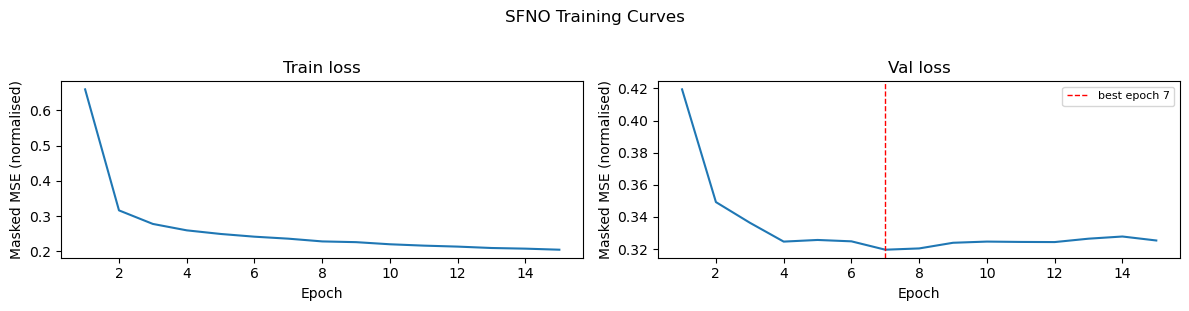

In [10]:
# ── Learning curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
epochs_ran = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs_ran, history["train_loss"], lw=1.5)
axes[1].plot(epochs_ran, history["val_loss"],   lw=1.5)
axes[1].axvline(best_epoch, color="red", lw=1, ls="--", label=f"best epoch {best_epoch}")
axes[1].legend(fontsize=8)
for ax, title in zip(axes, ["Train loss", "Val loss"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Masked MSE (normalised)")
    ax.set_title(title)
plt.suptitle("SFNO Training Curves", y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / "sfno_training_curve.png", dpi=150)
plt.show()

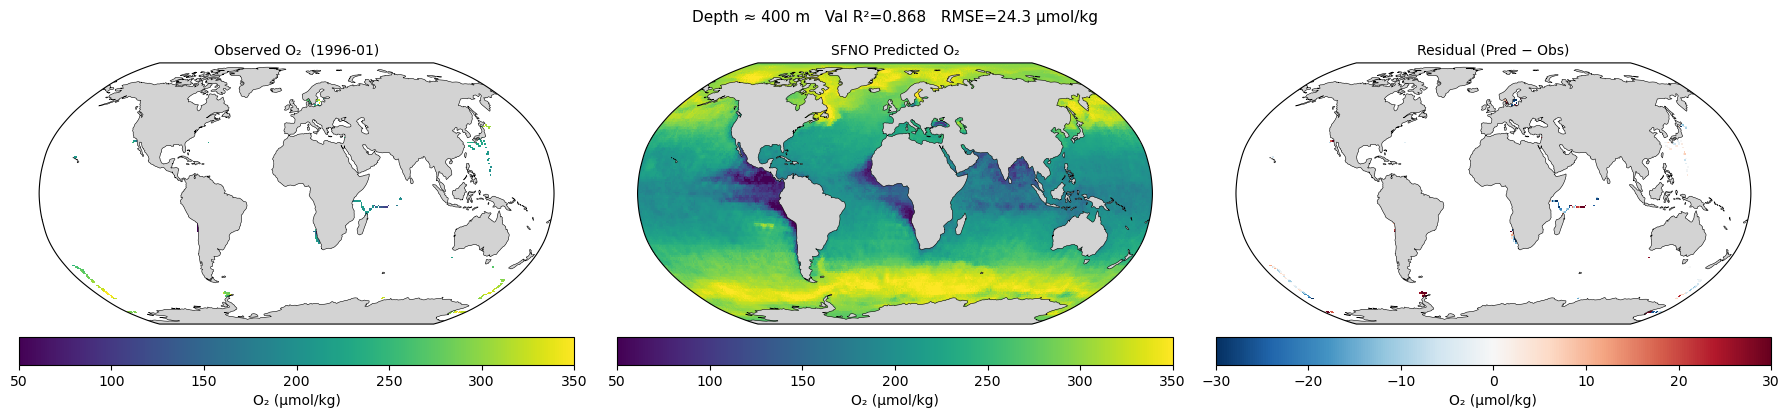

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Example map: first val month ───────────────────────────────────────────
ex_i     = 60
pred_map = pred_val[ex_i]
true_map = O2_maps[val_idx[ex_i]]
yr_ex, mo_ex = times[val_idx[ex_i]]

proj = ccrs.Robinson()
lons = np.linspace(-179.5, 179.5, 360)
lats = np.linspace(-89.5,  89.5,  180)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), subplot_kw={"projection": proj})
vmin, vmax = 50, 350

for ax, data, title in zip(
        axes,
        [true_map, pred_map, pred_map - true_map],
        [f"Observed O₂  ({yr_ex}-{mo_ex:02d})",
         "SFNO Predicted O₂",
         "Residual (Pred − Obs)"]):
    if "Residual" in title:
        cmap, norm = "RdBu_r", mcolors.CenteredNorm(halfrange=30)
    else:
        cmap, norm = "viridis", plt.Normalize(vmin, vmax)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.coastlines(linewidth=0.4, zorder=3)
    im = ax.pcolormesh(lons, lats, data, cmap=cmap, norm=norm,
                       transform=ccrs.PlateCarree(), zorder=1)
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, label="O₂ (μmol/kg)")
    ax.set_title(title, fontsize=10)

plt.suptitle(f"Depth ≈ {depth_val:.0f} m   Val R²={r2:.3f}   RMSE={rmse:.1f} μmol/kg",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / "sfno_example_map.png", dpi=150, bbox_inches="tight")
plt.show()

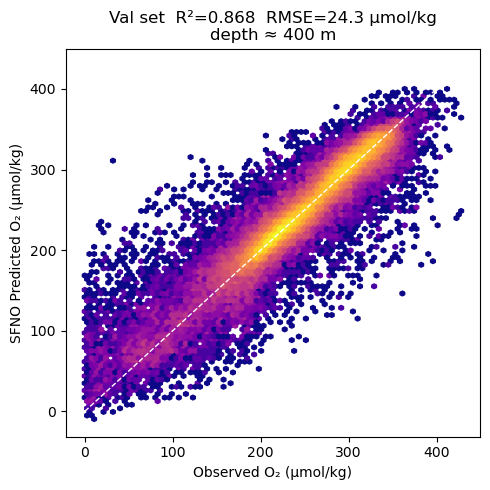

In [12]:
# ── Scatter: predicted vs observed (val months, ocean cells) ───────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(y_true, y_pred, gridsize=80, cmap="plasma", mincnt=1, bins="log")
lim = [y_true.min(), y_true.max()]
ax.plot(lim, lim, "w--", lw=1)
ax.set_xlabel("Observed O₂ (μmol/kg)")
ax.set_ylabel("SFNO Predicted O₂ (μmol/kg)")
ax.set_title(f"Val set  R²={r2:.3f}  RMSE={rmse:.1f} μmol/kg\ndepth ≈ {depth_val:.0f} m")
plt.tight_layout()
plt.savefig(SAVE_DIR / "sfno_scatter.png", dpi=150)
plt.show()